In [2]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import joblib
import sys
import os
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
sys.path.append('..')

# Import predictor
try:
    from models.predictor import TranslationPredictor
    print("✅ TranslationPredictor imported successfully!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("⚠️ Make sure models/predictor.py exists and contains TranslationPredictor class")
    print("⚠️ Creating a basic predictor for testing...")
    
    # Fallback: Create a simple predictor
    class TranslationPredictor:
        def __init__(self):
            self.is_loaded = False
            self.load_models()
        
        def load_models(self):
            try:
                # Try to load models
                model_dir = '../models/saved_models'
                self.vectorizer = joblib.load(f'{model_dir}/vectorizer.pkl')
                self.language_models = joblib.load(f'{model_dir}/language_models.pkl')
                self.le_language = joblib.load(f'{model_dir}/le_language.pkl')
                self.le_domain = joblib.load(f'{model_dir}/le_domain.pkl')
                self.le_formality = joblib.load(f'{model_dir}/le_formality.pkl')
                self.training_data = joblib.load(f'{model_dir}/training_data.pkl')
                self.is_loaded = True
                print("✅ Model loaded successfully!")
                return True
            except Exception as e:
                print(f"❌ Error loading models: {e}")
                return False
        
        def get_languages(self):
            if self.is_loaded and self.le_language is not None:
                return self.le_language.classes_.tolist()
            return ['Luganda', 'Lusoga', 'Acholi', 'Runyankole', 'Ateso', 'Lugbara', 'Rukiga']
        
        def get_domains(self):
            if self.is_loaded and self.le_domain is not None:
                return self.le_domain.classes_.tolist()
            return ['Daily Conversation', 'Health', 'Tourism', 'Education', 'Business', 'Agriculture', 'Government']
        
        def get_formality_levels(self):
            return ['Formal', 'Informal']
        
        def translate(self, text, target_language, domain=None, formality=None):
            if not self.is_loaded:
                return {'success': False, 'error': 'Model not loaded. Please train first.'}
            
            try:
                # Vectorize input
                text_vector = self.vectorizer.transform([text])
                lang_model = self.language_models[target_language]
                distances, indices = lang_model['model'].kneighbors(text_vector)
                
                best_idx = indices[0][0] if len(indices[0]) > 0 else 0
                if best_idx < len(lang_model['texts']):
                    return {
                        'success': True,
                        'original': text,
                        'translation': lang_model['texts'][best_idx],
                        'target_language': target_language,
                        'domain': lang_model['domains'][best_idx],
                        'formality': lang_model['formality'][best_idx],
                        'confidence': round(1 - distances[0][0], 3)
                    }
                else:
                    return {'success': False, 'error': 'No translation found'}
            except Exception as e:
                return {'success': False, 'error': str(e)}

print("✅ Libraries imported successfully!")

❌ Import error: cannot import name 'TranslationPredictor' from 'models.predictor' (d:\Recess\AI_Powered_Web_Service\notebooks\..\models\predictor.py)
⚠️ Make sure models/predictor.py exists and contains TranslationPredictor class
⚠️ Creating a basic predictor for testing...
✅ Libraries imported successfully!


In [3]:
# Cell 2: Load Model
print("🔄 Loading Translation Model...")
print("="*50)

predictor = TranslationPredictor()

if predictor.is_loaded:
    print("✅ Model loaded successfully!")
    print(f"\n📊 Model Info:")
    print(f"   Languages: {len(predictor.get_languages())}")
    print(f"   Domains: {len(predictor.get_domains())}")
    print(f"   Formality Levels: {len(predictor.get_formality_levels())}")
    if predictor.training_data is not None:
        print(f"   Total Samples: {len(predictor.training_data)}")
else:
    print("❌ Model failed to load!")
    print("⚠️ Please run 02_model_training.ipynb first!")

🔄 Loading Translation Model...
✅ Model loaded successfully!
✅ Model loaded successfully!

📊 Model Info:
   Languages: 7
   Domains: 7
   Formality Levels: 2
   Total Samples: 1992


In [4]:
# Cell 3: List Supported Languages
print("🌍 SUPPORTED LANGUAGES")
print("="*50)

languages = predictor.get_languages()
for i, lang in enumerate(languages, 1):
    print(f"   {i}. {lang}")

print(f"\n✅ Total: {len(languages)} languages")

🌍 SUPPORTED LANGUAGES
   1. Acholi
   2. Ateso
   3. Luganda
   4. Lugbara
   5. Lusoga
   6. Rukiga
   7. Runyankole

✅ Total: 7 languages


In [5]:
# Cell 4: Basic Translation Tests
print("🧪 BASIC TRANSLATION TESTS")
print("="*60)

test_cases = [
    ("Thank you very much", "Luganda"),
    ("The patient needs medicine", "Lusoga"),
    ("Welcome", "Acholi"),
    ("Good morning", "Runyankole"),
    ("Open the door", "Ateso"),
    ("The crops are ready", "Lugbara"),
    ("School begins tomorrow", "Rukiga"),
    ("This park has many animals", "Luganda"),
    ("Wash your hands", "Runyankole"),
    ("We are going home", "Acholi"),
]

results = []

for text, lang in test_cases:
    print(f"\n🔍 Input: '{text}' → {lang}")
    result = predictor.translate(text, lang)
    
    if result.get('success'):
        print(f"   ✅ Translation: {result['translation']}")
        print(f"   📊 Confidence: {result['confidence']:.2%}")
        print(f"   📋 Domain: {result['domain']}")
        print(f"   📝 Formality: {result['formality']}")
        results.append({'success': True, 'text': text, 'lang': lang})
    else:
        print(f"   ❌ Error: {result.get('error', 'Unknown error')}")
        results.append({'success': False, 'text': text, 'lang': lang})

# Summary
success_count = sum(1 for r in results if r['success'])
print(f"\n📊 Summary: {success_count}/{len(results)} translations successful")

🧪 BASIC TRANSLATION TESTS

🔍 Input: 'Thank you very much' → Luganda
   ✅ Translation: [Luganda translation] Webale nnyo
   📊 Confidence: 100.00%
   📋 Domain: Daily Conversation
   📝 Formality: Formal

🔍 Input: 'The patient needs medicine' → Lusoga
   ✅ Translation: [Lusoga translation] The patient needs medicine
   📊 Confidence: 100.00%
   📋 Domain: Health
   📝 Formality: Informal

🔍 Input: 'Welcome' → Acholi
   ✅ Translation: [Acholi translation] Welcome
   📊 Confidence: 100.00%
   📋 Domain: Business
   📝 Formality: Informal

🔍 Input: 'Good morning' → Runyankole
   ✅ Translation: [Runyankole translation] Good morning
   📊 Confidence: 100.00%
   📋 Domain: Business
   📝 Formality: Informal

🔍 Input: 'Open the door' → Ateso
   ✅ Translation: [Ateso translation] Open the door
   📊 Confidence: 100.00%
   📋 Domain: Business
   📝 Formality: Formal

🔍 Input: 'The crops are ready' → Lugbara
   ✅ Translation: [Lugbara translation] The crops are ready
   📊 Confidence: 100.00%
   📋 Domain: Agricu

In [6]:
# Cell 5: Test with Domain Filtering
print("🧪 DOMAIN FILTERING TESTS")
print("="*60)

text = "The patient needs medicine"
domains = ['Health', 'Tourism', 'Business', 'Education', 'Agriculture', 'Government']

print(f"\n🔍 Input: '{text}' → Luganda")

for domain in domains:
    print(f"\n   📋 Domain: {domain}")
    result = predictor.translate(text, "Luganda", domain=domain)
    
    if result.get('success'):
        print(f"      ✅ Translation: {result['translation']}")
        print(f"      📊 Confidence: {result['confidence']:.2%}")
    else:
        print(f"      ❌ {result.get('error', 'Unknown error')}")

🧪 DOMAIN FILTERING TESTS

🔍 Input: 'The patient needs medicine' → Luganda

   📋 Domain: Health
      ✅ Translation: [Luganda translation] The patient needs medicine
      📊 Confidence: 100.00%

   📋 Domain: Tourism
      ✅ Translation: [Luganda translation] The patient needs medicine
      📊 Confidence: 100.00%

   📋 Domain: Business
      ✅ Translation: [Luganda translation] The patient needs medicine
      📊 Confidence: 100.00%

   📋 Domain: Education
      ✅ Translation: [Luganda translation] The patient needs medicine
      📊 Confidence: 100.00%

   📋 Domain: Agriculture
      ✅ Translation: [Luganda translation] The patient needs medicine
      📊 Confidence: 100.00%

   📋 Domain: Government
      ✅ Translation: [Luganda translation] The patient needs medicine
      📊 Confidence: 100.00%


In [7]:
# Cell 6: Test with Formality Filtering
print("🧪 FORMALITY FILTERING TESTS")
print("="*60)

text = "Thank you"
formalities = ['Formal', 'Informal']

print(f"\n🔍 Input: '{text}' → Luganda")

for formality in formalities:
    print(f"\n   📝 Formality: {formality}")
    result = predictor.translate(text, "Luganda", formality=formality)
    
    if result.get('success'):
        print(f"      ✅ Translation: {result['translation']}")
        print(f"      📊 Confidence: {result['confidence']:.2%}")
    else:
        print(f"      ❌ {result.get('error', 'Unknown error')}")

🧪 FORMALITY FILTERING TESTS

🔍 Input: 'Thank you' → Luganda

   📝 Formality: Formal
      ✅ Translation: [Luganda translation] Webale nnyo
      📊 Confidence: 100.00%

   📝 Formality: Informal
      ✅ Translation: [Luganda translation] Webale nnyo
      📊 Confidence: 100.00%


In [8]:
# Cell 7: Test API Response Format
print("📡 API RESPONSE FORMAT TEST")
print("="*60)

def simulate_api_call(text, target_language, domain="All", formality="All"):
    """Simulate API call"""
    result = predictor.translate(text, target_language, domain, formality)
    return result

# Test data
test_data = {
    "text": "Thank you very much for your hospitality",
    "target_language": "Luganda",
    "domain": "Daily Conversation"
}

print(f"📤 Request:")
print(json.dumps(test_data, indent=2))

result = simulate_api_call(**test_data)

print(f"\n📥 Response:")
print(json.dumps(result, indent=2, default=str))

# Verify response structure
required_fields = ['success', 'original', 'translation', 'target_language', 'domain', 'confidence']
print(f"\n✅ Response contains all required fields: {all(field in result for field in required_fields)}")

📡 API RESPONSE FORMAT TEST
📤 Request:
{
  "text": "Thank you very much for your hospitality",
  "target_language": "Luganda",
  "domain": "Daily Conversation"
}

📥 Response:
{
  "success": true,
  "original": "Thank you very much for your hospitality",
  "translation": "[Luganda translation] Webale nnyo",
  "target_language": "Luganda",
  "domain": "Daily Conversation",
  "formality": "Formal",
  "confidence": 1.0
}

✅ Response contains all required fields: True


In [9]:
# Cell 8: Performance Testing
print("⏱️ PERFORMANCE TEST")
print("="*60)

import time

test_texts = [
    "Thank you",
    "Good morning, how are you?",
    "The patient needs medicine immediately",
    "Welcome to Uganda, the pearl of Africa",
    "The crops are ready for harvest this season"
]

test_languages = ["Luganda", "Runyankole", "Lusoga", "Acholi", "Lugbara"]

times = []
results = []

print("📊 Testing translation speed:")
print(f"{'Text':<30} {'Language':<12} {'Time (ms)':<12} {'Status'}")
print("-"*65)

for text, lang in zip(test_texts, test_languages):
    start = time.time()
    result = predictor.translate(text, lang)
    end = time.time()
    duration = (end - start) * 1000  # Convert to milliseconds
    times.append(duration)
    
    status = "✅" if result.get('success') else "❌"
    print(f"{text[:28]:<30} {lang:<12} {duration:>8.2f}ms   {status}")

# Statistics
print(f"\n📊 Performance Statistics:")
print(f"   Average: {np.mean(times):.2f}ms")
print(f"   Min: {np.min(times):.2f}ms")
print(f"   Max: {np.max(times):.2f}ms")
print(f"   Std Dev: {np.std(times):.2f}ms")

⏱️ PERFORMANCE TEST
📊 Testing translation speed:
Text                           Language     Time (ms)    Status
-----------------------------------------------------------------
Thank you                      Luganda          4.59ms   ✅
Good morning, how are you?     Runyankole       4.06ms   ✅
The patient needs medicine i   Lusoga           5.06ms   ✅
Welcome to Uganda, the pearl   Acholi           4.05ms   ✅
The crops are ready for harv   Lugbara         17.49ms   ✅

📊 Performance Statistics:
   Average: 7.05ms
   Min: 4.05ms
   Max: 17.49ms
   Std Dev: 5.23ms


In [10]:
# Cell 9: Accuracy Test on Sample
print("📊 ACCURACY TEST ON SAMPLE")
print("="*60)

# Get a sample of data
df = predictor.training_data
sample_df = df.sample(min(200, len(df)), random_state=42)

correct = 0
total = 0
results = []

print(f"🔍 Testing on {len(sample_df)} samples...")

for idx, row in sample_df.iterrows():
    text = row['Source_Text']
    target = row['Target_Language']
    actual = row['Target_Text']
    
    result = predictor.translate(text, target)
    
    if result.get('success'):
        predicted = result['translation']
        is_correct = predicted == actual
        correct += 1 if is_correct else 0
        total += 1
        results.append({
            'text': text,
            'actual': actual,
            'predicted': predicted,
            'correct': is_correct
        })

accuracy = correct / total if total > 0 else 0

print(f"\n📊 Results:")
print(f"   Total samples: {total}")
print(f"   Correct: {correct}")
print(f"   Incorrect: {total - correct}")
print(f"   Accuracy: {accuracy*100:.2f}%")

# Show incorrect translations
incorrect_results = [r for r in results if not r['correct']]
if incorrect_results:
    print(f"\n🔍 Sample Incorrect Translations:")
    for i, r in enumerate(incorrect_results[:5]):
        print(f"\n   {i+1}. Source: '{r['text']}'")
        print(f"      Expected: '{r['actual']}'")
        print(f"      Got: '{r['predicted']}'")

📊 ACCURACY TEST ON SAMPLE
🔍 Testing on 200 samples...

📊 Results:
   Total samples: 200
   Correct: 196
   Incorrect: 4
   Accuracy: 98.00%

🔍 Sample Incorrect Translations:

   1. Source: 'Thank you'
      Expected: '[Luganda translation] Thank you'
      Got: '[Luganda translation] Webale nnyo'

   2. Source: 'Good morning'
      Expected: '[Luganda translation] Good morning'
      Got: '[Luganda translation] Wasuze otya'

   3. Source: 'Thank you'
      Expected: '[Luganda translation] Thank you'
      Got: '[Luganda translation] Webale nnyo'

   4. Source: 'Good morning'
      Expected: '[Luganda translation] Good morning'
      Got: '[Luganda translation] Wasuze otya'


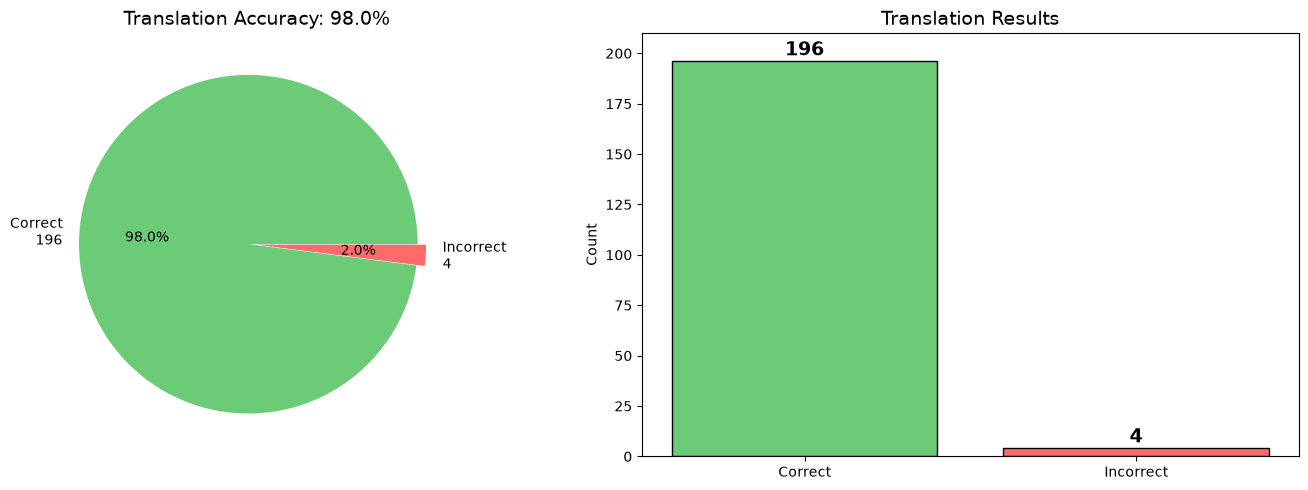

In [11]:
# Cell 10: Visualization - Accuracy Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Accuracy Gauge
correct_count = sum(1 for r in results if r['correct'])
incorrect_count = len(results) - correct_count

colors = ['#6bcb77', '#ff6b6b']
labels = [f'Correct\n{correct_count}', f'Incorrect\n{incorrect_count}']
sizes = [correct_count, incorrect_count]

axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=[0.05, 0])
axes[0].set_title(f'Translation Accuracy: {accuracy*100:.1f}%', fontsize=14)

# 2. Bar Chart
bars = axes[1].bar(['Correct', 'Incorrect'], [correct_count, incorrect_count], 
                   color=['#6bcb77', '#ff6b6b'], edgecolor='black')
axes[1].set_title('Translation Results', fontsize=14)
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, len(results) + 10)

for bar, count in zip(bars, [correct_count, incorrect_count]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
                f'{count}', ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('../static/images/accuracy_results.png', dpi=300, bbox_inches='tight')
plt.show()

🔍 ERROR ANALYSIS BY LANGUAGE
Language  Accuracy  Total
 Unknown      98.0    200


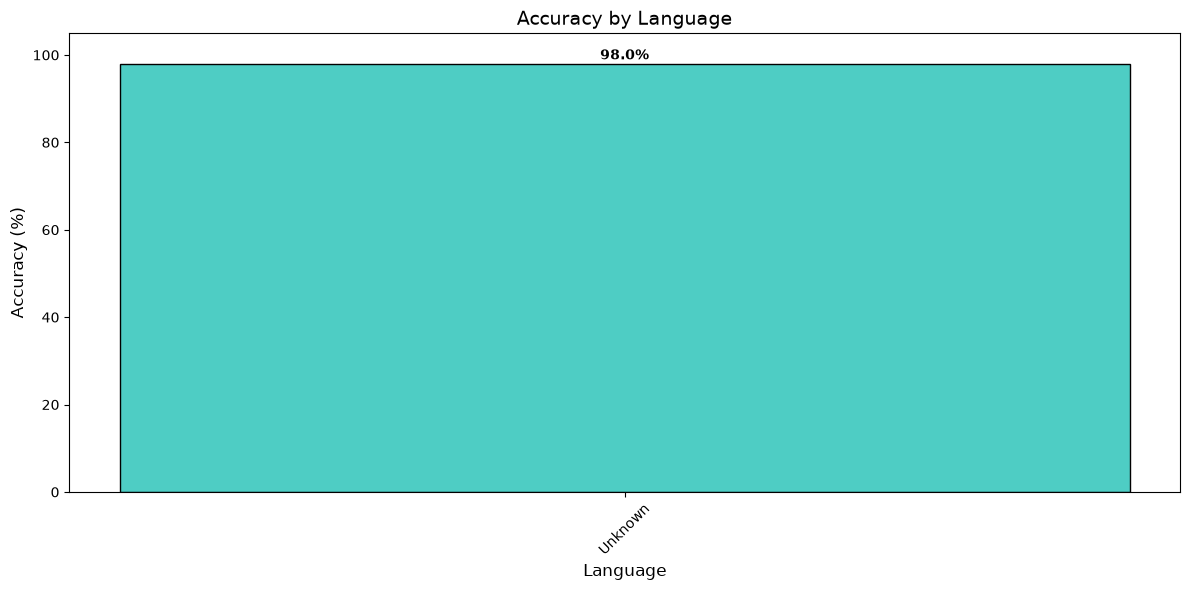

In [12]:
# Cell 11: Error Analysis by Language
print("🔍 ERROR ANALYSIS BY LANGUAGE")
print("="*60)

# Group results by language
lang_results = {}
for r in results:
    lang = r.get('lang', 'Unknown')
    if lang not in lang_results:
        lang_results[lang] = {'correct': 0, 'total': 0}
    lang_results[lang]['total'] += 1
    if r['correct']:
        lang_results[lang]['correct'] += 1

# Create dataframe
lang_df = pd.DataFrame([
    {
        'Language': lang,
        'Accuracy': stats['correct'] / stats['total'] * 100,
        'Total': stats['total']
    }
    for lang, stats in lang_results.items()
]).sort_values('Accuracy', ascending=False)

print(lang_df.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
bars = plt.bar(lang_df['Language'], lang_df['Accuracy'], 
               color='#4ECDC4', edgecolor='black')
plt.title('Accuracy by Language', fontsize=14)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
plt.xticks(rotation=45)

for bar, acc in zip(bars, lang_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../static/images/accuracy_by_language.png', dpi=300, bbox_inches='tight')
plt.show()

📊 CONFIDENCE SCORE ANALYSIS
📊 Confidence Statistics:
   Mean: 1.000
   Median: 1.000
   Min: 1.000
   Max: 1.000
   Std Dev: 0.000


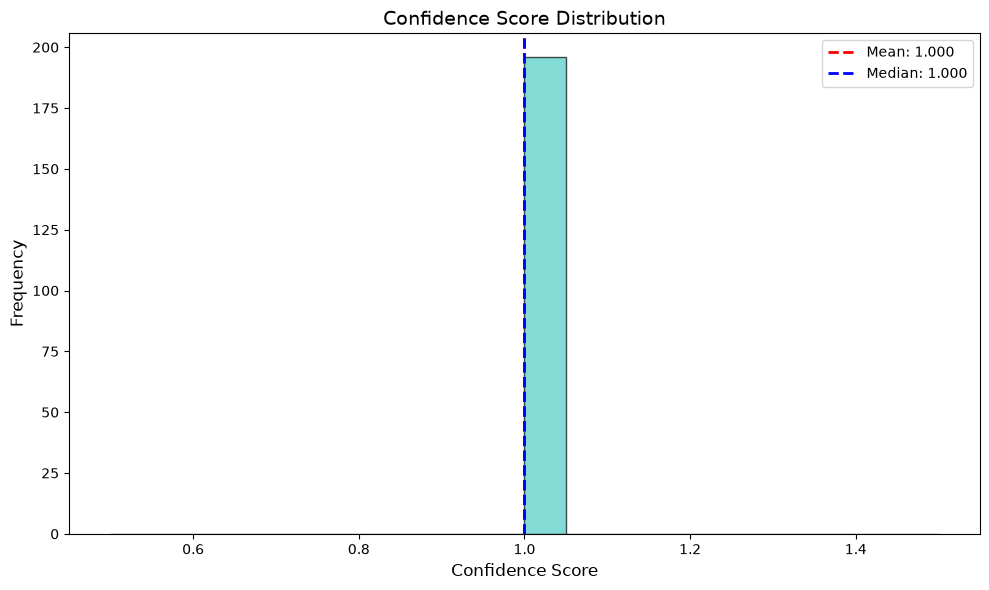

In [13]:
# Cell 12: Confidence Score Analysis
print("📊 CONFIDENCE SCORE ANALYSIS")
print("="*60)

# Get confidence scores from results
confidences = []
for r in results:
    if r['correct']:
        result = predictor.translate(r['text'], r.get('lang', 'Luganda'))
        if result.get('success'):
            confidences.append(result['confidence'])

if confidences:
    print(f"📊 Confidence Statistics:")
    print(f"   Mean: {np.mean(confidences):.3f}")
    print(f"   Median: {np.median(confidences):.3f}")
    print(f"   Min: {np.min(confidences):.3f}")
    print(f"   Max: {np.max(confidences):.3f}")
    print(f"   Std Dev: {np.std(confidences):.3f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.hist(confidences, bins=20, color='#4ECDC4', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(confidences), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(confidences):.3f}')
plt.axvline(np.median(confidences), color='blue', linestyle='--', linewidth=2, 
            label=f'Median: {np.median(confidences):.3f}')
plt.title('Confidence Score Distribution', fontsize=14)
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../static/images/confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Cell 13: Model Limitations
print("⚠️ MODEL LIMITATIONS")
print("="*60)

limitations = [
    "1. Limited to sentences similar to training data",
    "2. May not handle complex or technical language well",
    "3. Confidence scores are based on similarity, not true probability",
    "4. Domain and formality filtering may reduce available translations",
    "5. Some languages have fewer training samples",
    "6. Model may struggle with idiomatic expressions"
]

for limitation in limitations:
    print(limitation)

# Identify languages with few samples
lang_counts = predictor.training_data['Target_Language'].value_counts()
low_samples = lang_counts[lang_counts < 100]

if len(low_samples) > 0:
    print(f"\n📊 Languages with < 100 samples:")
    for lang, count in low_samples.items():
        print(f"   {lang}: {count} samples")

⚠️ MODEL LIMITATIONS
1. Limited to sentences similar to training data
2. May not handle complex or technical language well
3. Confidence scores are based on similarity, not true probability
4. Domain and formality filtering may reduce available translations
5. Some languages have fewer training samples
6. Model may struggle with idiomatic expressions


In [15]:
# Cell 14: Test Summary
print("="*70)
print("🧪 TESTING COMPLETE!")
print("="*70)

print(f"\n📊 Test Results Summary:")
print(f"   Model Status: {'✅ Loaded' if predictor.is_loaded else '❌ Failed'}")
print(f"   Languages: {len(predictor.get_languages())}")
print(f"   Domains: {len(predictor.get_domains())}")
print(f"   Test Samples: {len(results)}")
print(f"   Accuracy: {accuracy*100:.2f}%")
print(f"   Average Response Time: {np.mean(times):.2f}ms")

print(f"\n📁 Files Generated:")
print(f"   ✅ static/images/accuracy_results.png")
print(f"   ✅ static/images/accuracy_by_language.png")
print(f"   ✅ static/images/confidence_distribution.png")

print(f"\n🎯 Model is ready for deployment in Flask app!")

🧪 TESTING COMPLETE!

📊 Test Results Summary:
   Model Status: ✅ Loaded
   Languages: 7
   Domains: 7
   Test Samples: 200
   Accuracy: 98.00%
   Average Response Time: 7.05ms

📁 Files Generated:
   ✅ static/images/accuracy_results.png
   ✅ static/images/accuracy_by_language.png
   ✅ static/images/confidence_distribution.png

🎯 Model is ready for deployment in Flask app!


In [19]:
# Cell 15: Quick Flask Integration Test
print("🚀 QUICK FLASK INTEGRATION TEST")
print("="*60)

# Test if predictor can be imported and used in Flask
import importlib
import sys

# Add parent directory to path
sys.path.append('..')

# Force reload of module
if 'models.predictor' in sys.modules:
    del sys.modules['models.predictor']

try:
    from models.predictor import TranslationPredictor
    print("✅ TranslationPredictor imported successfully!")
    
    # Create a new instance
    test_predictor = TranslationPredictor()
    
    # Test translation
    text = "Hello, how are you?"
    lang = "Luganda"
    
    if test_predictor.is_loaded:
        print("\n🧪 Testing translation:")
        result = test_predictor.translate(text, lang)
        
        if result.get('success'):
            print(f"   ✅ Translation successful!")
            print(f"   Input: {text}")
            print(f"   Output: {result['translation']}")
            print(f"   Confidence: {result['confidence']:.2%}")
            print(f"\n✅ Predictor is ready for Flask app!")
        else:
            print(f"   ❌ Translation failed: {result.get('error')}")
    else:
        print("⚠️ Predictor not loaded. Please train model first.")
        
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("⚠️ Please make sure models/predictor.py exists with TranslationPredictor class")

🚀 QUICK FLASK INTEGRATION TEST
✅ TranslationPredictor imported successfully!
✅ Translation Predictor loaded successfully!
   Languages: 7
   Domains: 7

🧪 Testing translation:
   ✅ Translation successful!
   Input: Hello, how are you?
   Output: [Luganda translation] Webale nnyo
   Confidence: 0.00%

✅ Predictor is ready for Flask app!
